Titanic Survival Prediction - ML Algorithms Comparison


Import Libraries

In [143]:
#Data 
import numpy as np
import pandas as pd

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Sklearn preprocessing lib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder,OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Sklearn Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


#warnings
import warnings
warnings.filterwarnings('ignore')


Load Datasets


In [144]:
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Exploratory Data Analysis

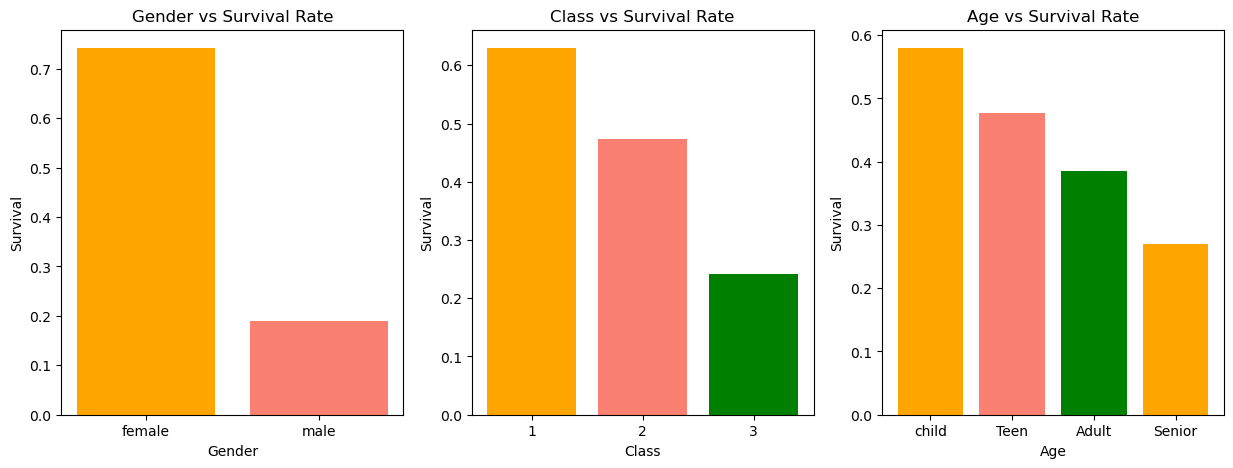

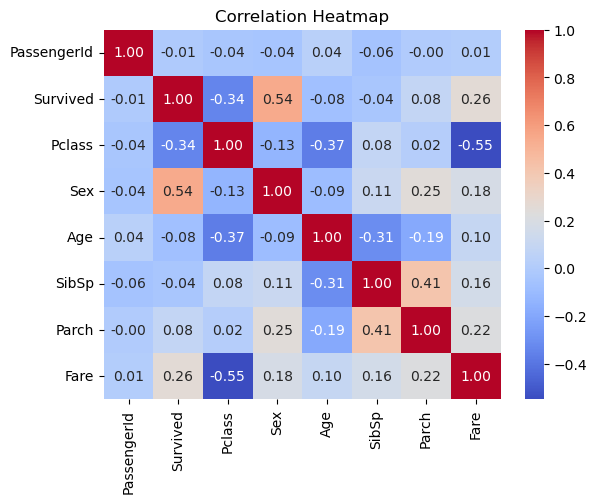

In [145]:
df.shape
# df.info()

df["Survived"].value_counts

gender_result = df.groupby('Sex')['Survived'].mean()
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
class_result = df.groupby("Pclass")['Survived'].mean()
bins = [0, 12, 17, 59, 100]
labels = ['child', 'Teen', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
age_result = df.groupby('AgeGroup')['Survived'].mean()


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
#plot 1
axes[0].bar(gender_result.index, gender_result.values, color=['orange', 'salmon', 'green'])
axes[0].set_title("Gender vs Survival Rate")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Survival")

#plot 2
axes[1].bar(class_result.index, class_result.values, color=['orange', 'salmon', 'green'])
axes[1].set_title("Class vs Survival Rate")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Survival")
axes[1].set_xticks([1, 2, 3])

#plot 3
axes[2].bar(age_result.index, age_result.values, color=['orange', 'salmon', 'green'])
axes[2].set_title("Age vs Survival Rate")
axes[2].set_xlabel("Age")
axes[2].set_ylabel("Survival")


plt.figure()
corr_matrix = df.select_dtypes(include='number').corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()





Data PreProcessing

In [146]:
#Filling missing Values
age_median = df['Age'].median()
df['Age'].fillna(age_median, inplace=True)

df.drop(columns=["Cabin", "Name", "PassengerId", "Ticket"], inplace=True)
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)
df.head()




# #Train Test Split
y = df['Survived']
X = df[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "AgeGroup", "Embarked_Q" ,"Embarked_S"]]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)






Model Training 

Model Comparison

Best Model Deep Dive